In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import frites.conn
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [7]:
def _regionPETH(session,regs=None,when=None,limits=None):

    # load data
    R = rg.data.Regions(session,events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events = {}
    for name in ['ripples','deltaWaves','spindles']:
        try:
            ev, _ = fma.data.loadEvents(session,name)
            events[name] = ev[name]['col1'] if 'col1' in ev[name] else ev[name]['peaks']
        except:
            events[name] = []

    # assess coupling
    is_coupled = {}
    is_coupled['ripples'], is_coupled['deltasr'] = isru.isCoupled(events['ripples'],events['deltaWaves'],[0.05,0.25]) # [0.05,0.25]
    is_coupled['deltass'], is_coupled['spindles'] = isru.isCoupled(events['deltaWaves'],events['spindles'],[0.1,1.3]) # [0.1,1.3]
    is_coupled['deltaWaves'] = is_coupled['deltasr'] & is_coupled['deltass']
    is_coupled['deltasr'][is_coupled['deltaWaves']] = False # deltasr contains delta waves just coupled to ripples
    is_coupled['deltass'][is_coupled['deltaWaves']] = False # deltass contains delta waves just coupled to spindles
    is_coupled['deltasn'] = ~is_coupled['deltasr'] & ~is_coupled['deltass'] # deltas coupled to no event

    fr = R.firingRate(regs=regs,norm=True)
    fr_peth = {}
    for n in ['ripples','spindles']:
        fr_p, t_fr, _ = fma.analysis.PETH(fr,events[n][is_coupled[n]],limits=limits,n_bins=101,fast=True) # (events, time, regions)
        fr_peth[n] = xr.DataArray(fr_p,dims=['events','t','reg'],coords={'t': t_fr, 'reg': regs, 'rat': int(R.rat), 'base': R.basename})
        fr_p, t_fr, _ = fma.analysis.PETH(fr,events[n][~is_coupled[n]],limits=limits,n_bins=101,fast=True) # (events, time, regions)
        fr_peth[f'{n}_n'] = xr.DataArray(fr_p,dims=['events','t','reg'],coords={'t': t_fr, 'reg': regs, 'rat': int(R.rat), 'base': R.basename})
    for n in ['deltasr','deltaWaves','deltass']:
        fr_p, t_fr, _ = fma.analysis.PETH(fr,events['deltaWaves'][is_coupled[n]],limits=limits,n_bins=101,fast=True) # (events, time, regions)
        fr_peth[n] = xr.DataArray(fr_p,dims=['events','t','reg'],coords={'t': t_fr, 'reg': regs, 'rat': int(R.rat), 'base': R.basename})
    fr_p, t_fr, _ = fma.analysis.PETH(fr,events['deltaWaves'][is_coupled['deltasn']],limits=limits,n_bins=101,fast=True) # (events, time, regions)
    fr_peth['deltas_n'] = xr.DataArray(fr_p,dims=['events','t','reg'],coords={'t': t_fr, 'reg': regs, 'rat': int(R.rat), 'base': R.basename})

    fit_rip = frites.conn.conn_fit(
        xr.concat((fr_peth['ripples'],fr_peth['ripples_n']), dim=xr.DataArray([0]*len(fr_peth['ripples'])+[1]*len(fr_peth['ripples_n']), dims='events',name='events')).transpose('events','reg','t'),
        y='events', roi='reg', times='t', mi_type='cd', max_delay=.3, verbose=False)
    fit_rip = fit_rip.assign_coords(rat=int(R.rat))

    return fr_peth, fit_rip

In [8]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][9]
print(session)
fr_peth, fit_rip = _regionPETH(session,limits=[-.5,.5])
#events = ['ripples','deltas','spindles','OFF -> ON','ON -> OFF']

/mnt/hubel-data-131/perceval/Rat003_20231224/Rat003_20231224.xml


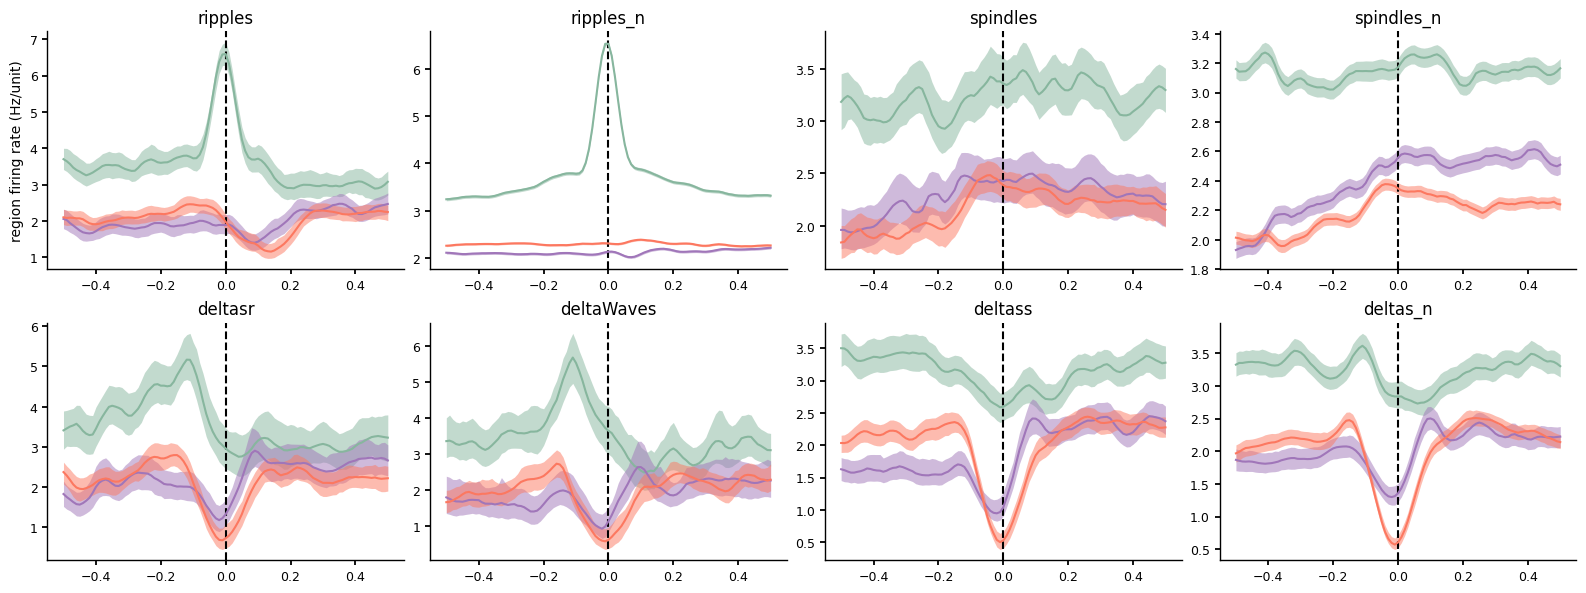

In [5]:
# see PETHS
fig, ax = fma.plotting.makeFigure(n=[2,len(fr_peth)//2],size=[40,15])
for i, (name, fr_p) in enumerate(fr_peth.items()):
    j, k = np.unravel_index(i,(2,len(fr_peth)//2))
    ax[j,k].set_title(name)
    ax[j,k].axvline(0,color='k',ls='--')
    for r in fr_p['reg'].values:
        fma.plotting.semPlot(fr_p['t'],fr_p.sel(reg=r),zscore=False,color=isru.paperColors(r),ax=ax[j,k])
ax[0,0].set(ylabel='region firing rate (Hz/unit)');

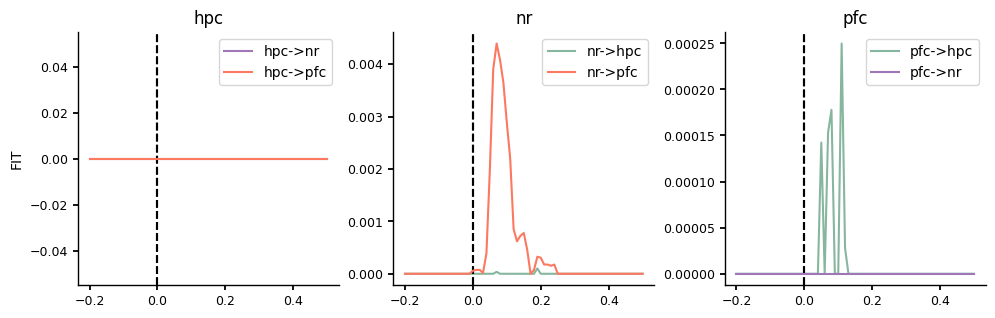

In [10]:
# see FIT
fig, ax = fma.plotting.makeFigure(n=[1,len(fit_rip)//2],size=[25,8])
for i, r in enumerate(fit_rip['roi'].values):
    ax[i//2].set_title(r.split('-')[0])
    ax[i//2].axvline(0,color='k',ls='--')
    ax[i//2].plot(fit_rip['times'],fit_rip.sel(roi=r),color=isru.paperColors(r.split('>')[1]),label=r)
    ax[i//2].legend()
ax[0].set(ylabel='FIT');

run batch

In [10]:
fr_peth, fit_rip = fma.data.runBatch(batch_file,_regionPETH,kwargs={'limits': [-.5,.5]},parallel=True)
# concatenate sessions
frp_cat = {}
for i in fr_peth[0]:
    frp_cat[i] = xr.concat([d[i].mean(dim='events') for d in fr_peth if d is not None],dim='rat',join='outer') # list of (rat, t, region)
frp_avg = {i: frp.groupby('rat').mean(dim='rat',skipna=True) for i, frp in frp_cat.items()} # average per animal

fitr_cat = xr.concat([d for d in fit_rip if d is not None],dim='rat',join='outer')
fitr_avg = fitr_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-06-23 11:51:54.381074 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230817/Rat002_20230817.xml (36)
only integer scalar array

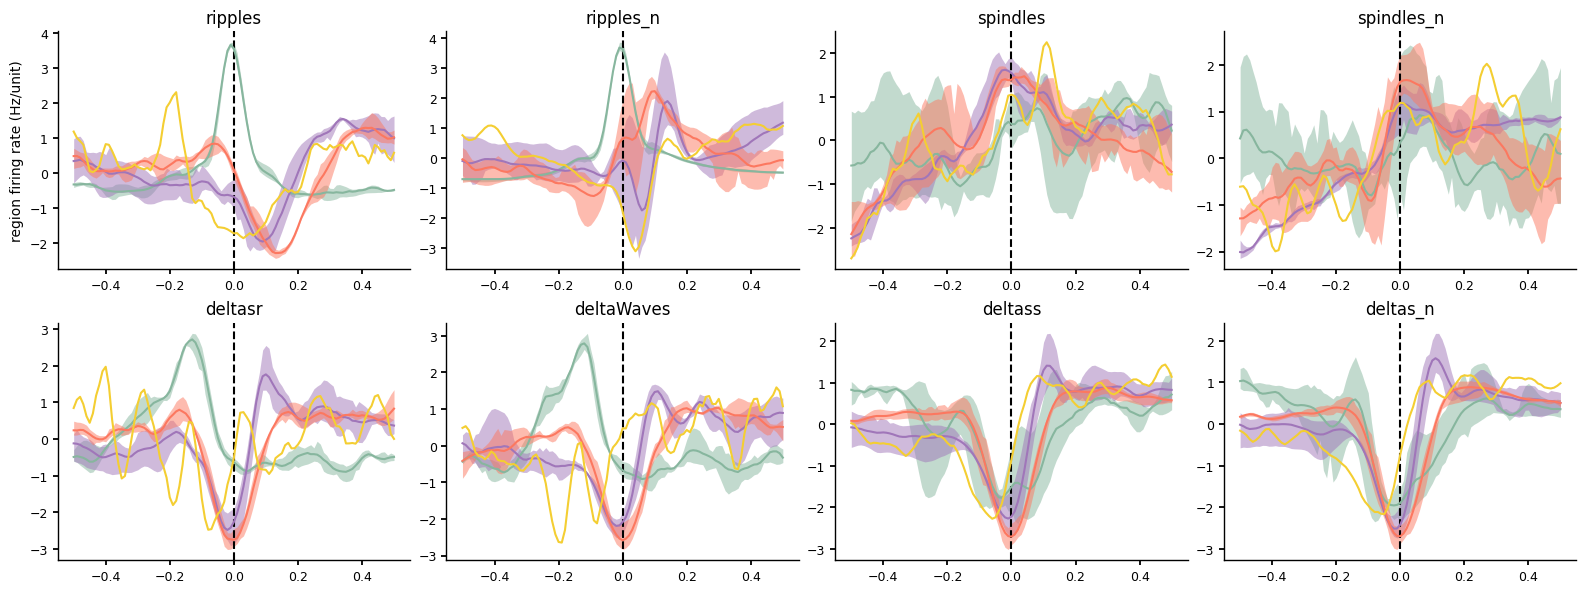

In [21]:
fig, ax = fma.plotting.makeFigure(n=[2,len(frp_avg)//2],size=[40,15])
for i, (name, fr_p) in enumerate(frp_avg.items()):
    j, k = np.unravel_index(i,(2,len(frp_avg)//2))
    ax[j,k].set_title(name)
    ax[j,k].axvline(0,color='k',ls='--')
    for r in fr_p['reg'].values:
        #ax[i].plot(fr_p['t'],fr_p.sel(reg=r).T,color=isru.paperColors(r))
        fma.plotting.semPlot(fr_p['t'],fr_p.sel(reg=r),zscore=2,color=isru.paperColors(r),ax=ax[j,k])
ax[0,0].set(ylabel='region firing rate (Hz/unit)');

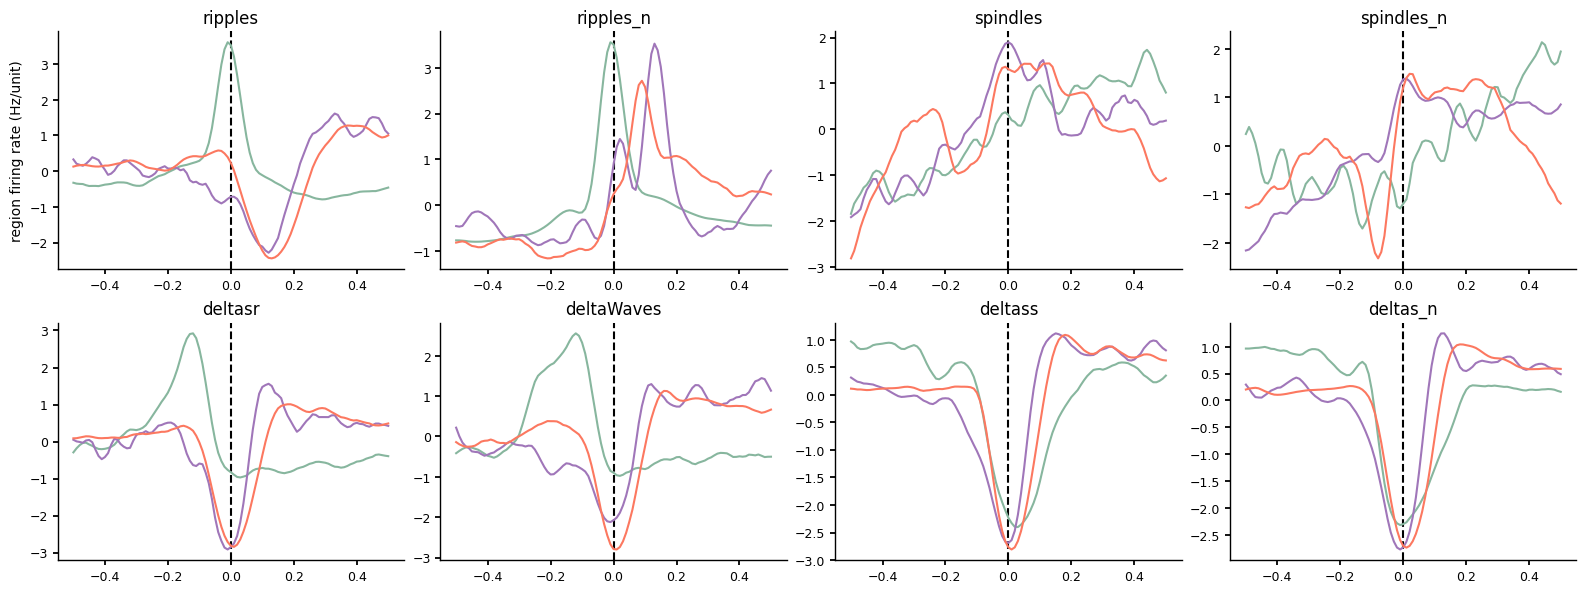

In [32]:
 # see per animal
rat = 4
fig, ax = fma.plotting.makeFigure(n=[2,len(frp_avg)//2],size=[40,15])
for i, (name, fr_p) in enumerate(frp_avg.items()):
    j, k = np.unravel_index(i,(2,len(frp_avg)//2))
    ax[j,k].set_title(name)
    ax[j,k].axvline(0,color='k',ls='--')
    for r in fr_p['reg'].values:
        fma.plotting.semPlot(fr_p['t'],fr_p.sel(reg=r,rat=rat),zscore=2,color=isru.paperColors(r),ax=ax[j,k])
ax[0,0].set(ylabel='region firing rate (Hz/unit)');

/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


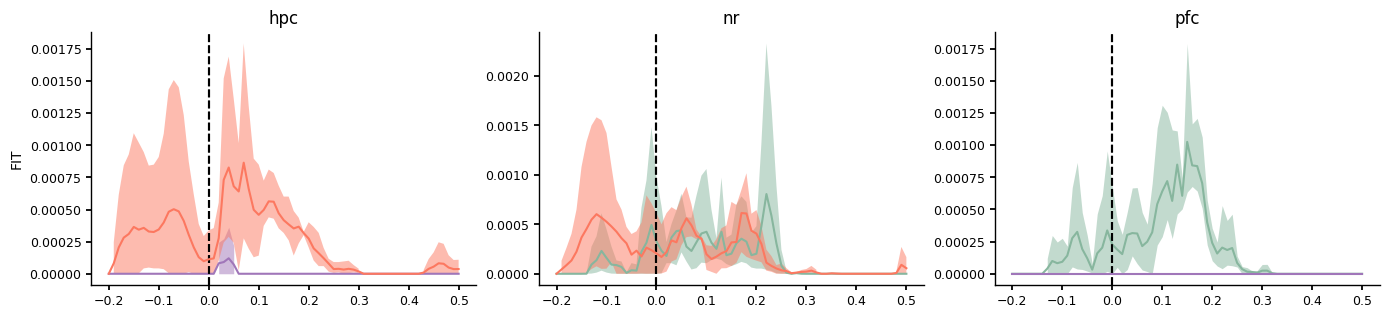

In [19]:
# see FIT
fitr_plot = fitr_avg.sel(roi=~fitr_avg.roi.str.contains('th'))
fig, ax = fma.plotting.makeFigure(n=[1,len(fitr_plot['roi'])//2],size=[35,8])
for i, r in enumerate(fitr_plot['roi'].values):
    ax[i//2].set_title(r.split('-')[0])
    ax[i//2].axvline(0,color='k',ls='--')
    fma.plotting.semPlot(fitr_plot['times'],fitr_plot.sel(roi=r),color=isru.paperColors(r.split('>')[1]),ax=ax[i//2])
ax[0].set(ylabel='FIT');